In [ ]:
# Student name: Amir Gharghabi
# Course: ML
# HW4
# Q5

In [2]:
import tensorflow as tf

In [3]:
from tensorflow.keras.datasets import mnist
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
# Specify the path to the locally downloaded MNIST dataset file
local_file_path = "mnist.npz"

# Load the MNIST dataset from the local file
with np.load(local_file_path) as data:
    train_images, train_labels = data["x_train"], data["y_train"]
    test_images, test_labels = data["x_test"], data["y_test"]

# Print the shape of the loaded data
print("Train Images Shape:", train_images.shape)
print("Train Labels Shape:", train_labels.shape)
print("Test Images Shape:", test_images.shape)
print("Test Labels Shape:", test_labels.shape)

Train Images Shape: (60000, 28, 28)
Train Labels Shape: (60000,)
Test Images Shape: (10000, 28, 28)
Test Labels Shape: (10000,)


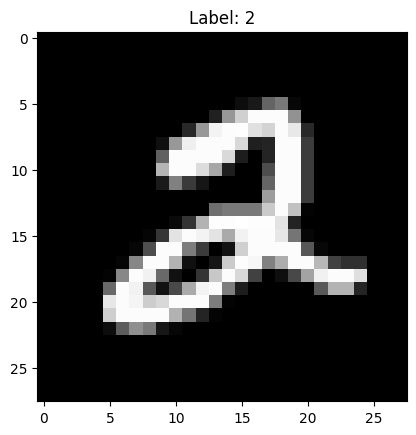

In [6]:
plt.imshow(train_images[5], cmap='gray')
plt.title(f"Label: {train_labels[5]}")
plt.show()

In [7]:
train_images[5].shape

(28, 28)

In [8]:
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

In [9]:
total_samples = len(train_images)
split_ratio = 0.2
val_samples = int(total_samples * split_ratio)

# Split the data into training and validation sets
val_images, train_images = train_images[:val_samples], train_images[val_samples:]
val_labels, train_labels = train_labels[:val_samples], train_labels[val_samples:]


In [10]:
import numpy as np
from tensorflow.keras import layers, models
from sklearn.metrics import accuracy_score

In [11]:
print("_________")
print(train_images.shape)
print("_________")
print(val_images.shape)
print("_________")
print(test_images.shape)

_________
(48000, 28, 28)
_________
(12000, 28, 28)
_________
(10000, 28, 28)


In [ ]:
# ________________________________________

# _____ M L P ____________________________

# ________________________________________

In [12]:
# Build the MLP model
model = models.Sequential()
model.add(layers.Flatten(input_shape=(28, 28)))  # Flatten the 28x28 images to a 1D array
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model and store the training history
epochs_num = 20
history = model.fit(train_images, train_labels, epochs=epochs_num, validation_data=(val_images, val_labels))



Epoch 1/20


1500/1500 [==============================] - 8s 3ms/step - loss: 0.2844 - accuracy: 0.9192 - val_loss: 0.1643 - val_accuracy: 0.9522
Epoch 2/20
1500/1500 [==============================] - 4s 2ms/step - loss: 0.1259 - accuracy: 0.9630 - val_loss: 0.1142 - val_accuracy: 0.9665
Epoch 3/20
1500/1500 [==============================] - 5s 3ms/step - loss: 0.0856 - accuracy: 0.9741 - val_loss: 0.1054 - val_accuracy: 0.9693
Epoch 4/20
1500/1500 [==============================] - 4s 2ms/step - loss: 0.0643 - accuracy: 0.9797 - val_loss: 0.0976 - val_accuracy: 0.9705
Epoch 5/20
1500/1500 [==============================] - 4s 2ms/step - loss: 0.0481 - accuracy: 0.9852 - val_loss: 0.0933 - val_accuracy: 0.9716
Epoch 6/20
1500/1500 [==============================] - 4s 3ms/step - loss: 0.0378 - accuracy: 0.9884 - val_loss: 0.0829 - val_accuracy: 0.9769
Epoch 7/20
1500/1500 [==============================] - 5s 3ms/step - loss: 0.0294 - accuracy: 0.9910 - val_loss: 0.0880 - val_accur

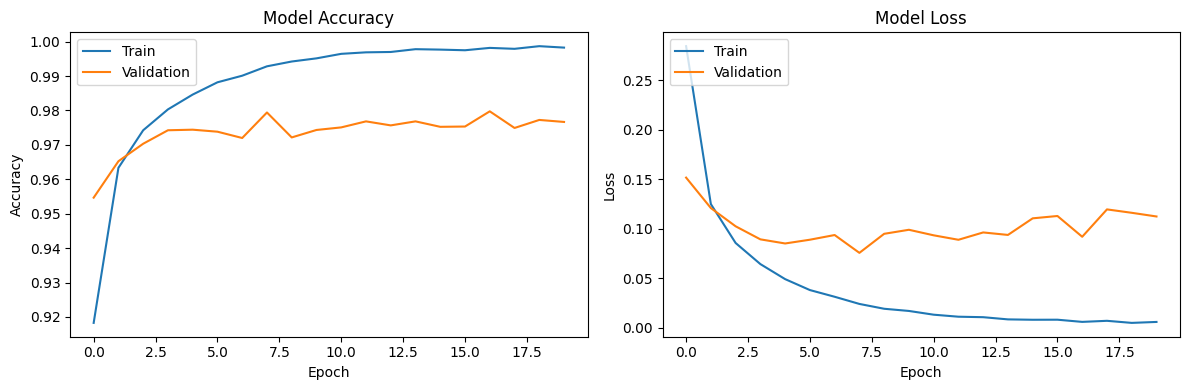

In [33]:
# Plot the learning curves
plt.figure(figsize=(12, 4))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [34]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

313/313 [==============================] - 1s 1ms/step - loss: 0.1140 - accuracy: 0.9755
Test Accuracy: 97.55%


In [43]:
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

313/313 [==============================] - 0s 1ms/step
Accuracy on the test set: 97.55%


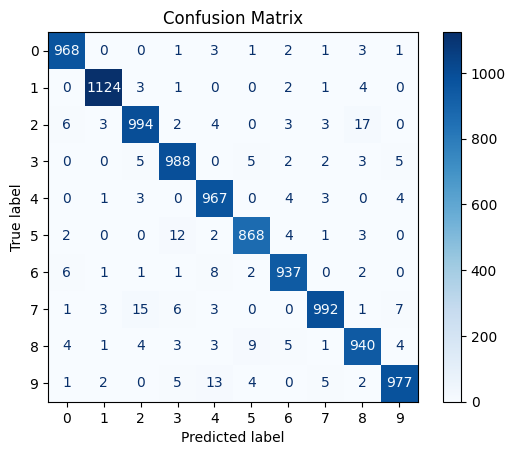

In [36]:
predictions = np.argmax(model.predict(test_images), axis=1)

# Calculate accuracy on the test set
test_set_accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy on the test set: {test_set_accuracy * 100:.2f}%")

# Create the confusion matrix
cm = confusion_matrix(test_labels, predictions)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
disp.plot(cmap='Blues', values_format='d')

plt.title('Confusion Matrix')
plt.show()

In [1]:
# ________________________________________

# _____ C N N ____________________________

# ________________________________________

In [38]:
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

In [39]:
    train_labels = to_categorical(train_labels)
    val_labels = to_categorical(val_labels)
    test_labels = to_categorical(test_labels)
    
    # Build the CNN model
    model = models.Sequential()
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))
    
    # Compile the model
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    # Train the model
    history = model.fit(train_images, train_labels, epochs=10, batch_size=64, validation_data=(val_images, val_labels))
    
    # Evaluate the model on the test set
    test_loss, test_acc = model.evaluate(test_images, test_labels)
    print(f'Test accuracy: {test_acc}')


Epoch 1/10
750/750 [==============================] - 14s 16ms/step - loss: 0.2036 - accuracy: 0.9379 - val_loss: 0.0840 - val_accuracy: 0.9743
Epoch 2/10
750/750 [==============================] - 14s 18ms/step - loss: 0.0588 - accuracy: 0.9816 - val_loss: 0.0602 - val_accuracy: 0.9811
Epoch 3/10
750/750 [==============================] - 14s 19ms/step - loss: 0.0404 - accuracy: 0.9871 - val_loss: 0.0567 - val_accuracy: 0.9832
Epoch 4/10
750/750 [==============================] - 14s 19ms/step - loss: 0.0319 - accuracy: 0.9899 - val_loss: 0.0425 - val_accuracy: 0.9876
Epoch 5/10
750/750 [==============================] - 14s 19ms/step - loss: 0.0243 - accuracy: 0.9921 - val_loss: 0.0387 - val_accuracy: 0.9882
Epoch 6/10
750/750 [==============================] - 15s 20ms/step - loss: 0.0210 - accuracy: 0.9933 - val_loss: 0.0396 - val_accuracy: 0.9887
Epoch 7/10
750/750 [==============================] - 15s 20ms/step - loss: 0.0168 - accuracy: 0.9941 - val_loss: 0.0406 - val_accuracy

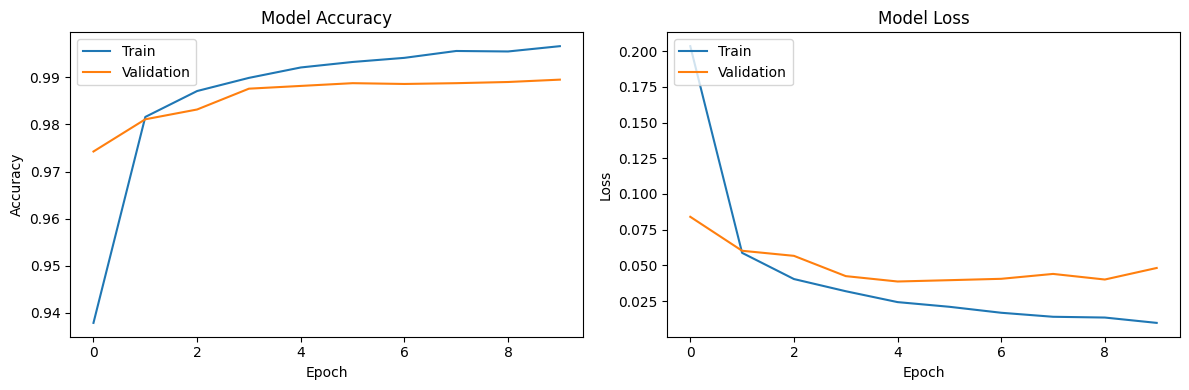

In [41]:
# Plot the learning curves
plt.figure(figsize=(12, 4))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [40]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

313/313 [==============================] - 1s 3ms/step - loss: 0.0353 - accuracy: 0.9901
Test Accuracy: 99.01%


313/313 [==============================] - 1s 3ms/step


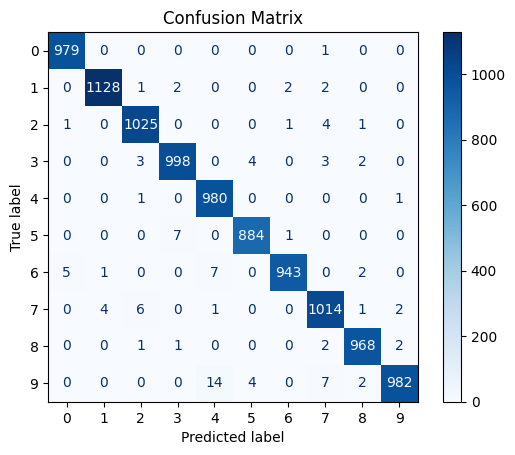

In [46]:
predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

# Compute confusion matrix
cm = confusion_matrix(np.argmax(test_labels, axis=1), predicted_labels)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# ________________________________________

# _____ MobileNet ____________________________

# ________________________________________

In [2]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import img_to_array, array_to_img


he


In [5]:
import matplotlib.pyplot as plt

In [7]:
# Load your dataset
local_file_path = "mnist.npz"
with np.load(local_file_path) as data:
    train_images, train_labels = data["x_train"], data["y_train"]
    test_images, test_labels = data["x_test"], data["y_test"]
num_classes = 10


# Use only half of the dataset
train_images = train_images[:len(train_images)//50]
train_labels = train_labels[:len(train_labels)//50]
test_images = test_images[:len(test_images)//50]
test_labels = test_labels[:len(test_labels)//50]

# Reshape and duplicate channels for grayscale images
train_images_resized = np.array([np.repeat(img[:, :, np.newaxis], 3, axis=2) for img in train_images])
test_images_resized = np.array([np.repeat(img[:, :, np.newaxis], 3, axis=2) for img in test_images])

# Resize images to (224, 224) to match the expected input shape of MobileNet
train_images_resized = np.array([img_to_array(array_to_img(img).resize((224, 224))) for img in train_images_resized])
test_images_resized = np.array([img_to_array(array_to_img(img).resize((224, 224))) for img in test_images_resized])

# Preprocess the images for MobileNet
train_images_preprocessed = preprocess_input(train_images_resized)
test_images_preprocessed = preprocess_input(test_images_resized)

# Load MobileNet model without top (classification) layers
base_model = MobileNet(weights=None, include_top=False, input_shape=(224, 224, 3))
base_model.load_weights('mobilenet_1_0_224_tf_no_top.h5')

# Freeze the pre-trained layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom top layers for your specific classification task
x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(num_classes, activation='softmax')(x)

# Create the model
model = Model(inputs=base_model.input, outputs=output)

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(train_images_preprocessed, train_labels, epochs=10, validation_data=(test_images_preprocessed, test_labels))


Epoch 1/10
38/38 [==============================] - 23s 536ms/step - loss: 1.3620 - accuracy: 0.5433 - val_loss: 0.6031 - val_accuracy: 0.8400
Epoch 2/10
38/38 [==============================] - 22s 582ms/step - loss: 0.5365 - accuracy: 0.8267 - val_loss: 0.4154 - val_accuracy: 0.8750
Epoch 3/10
38/38 [==============================] - 22s 592ms/step - loss: 0.3479 - accuracy: 0.8958 - val_loss: 0.3083 - val_accuracy: 0.9100
Epoch 4/10
38/38 [==============================] - 23s 602ms/step - loss: 0.2569 - accuracy: 0.9308 - val_loss: 0.2894 - val_accuracy: 0.9100
Epoch 5/10
38/38 [==============================] - 23s 607ms/step - loss: 0.2318 - accuracy: 0.9300 - val_loss: 0.2449 - val_accuracy: 0.9300
Epoch 6/10
38/38 [==============================] - 25s 655ms/step - loss: 0.1962 - accuracy: 0.9358 - val_loss: 0.2325 - val_accuracy: 0.9200
Epoch 7/10
38/38 [==============================] - 24s 627ms/step - loss: 0.1631 - accuracy: 0.9542 - val_loss: 0.1903 - val_accuracy: 0.9300

7/7 [==============================] - 2s 307ms/step - loss: 0.1827 - accuracy: 0.9250
Test accuracy: 0.925000011920929


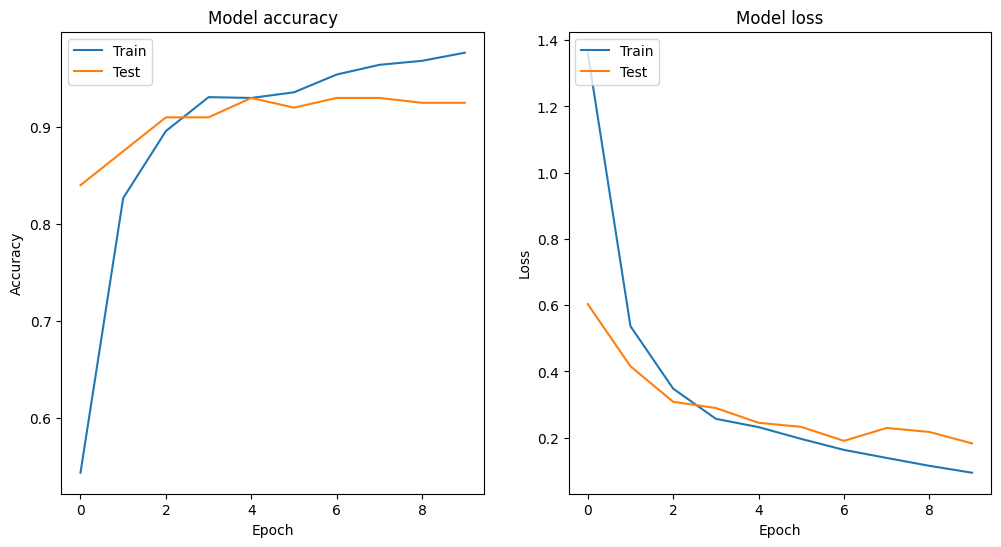

In [8]:


# Evaluate the model
test_loss, test_acc = model.evaluate(test_images_preprocessed, test_labels)
print(f'Test accuracy: {test_acc}')

# Plot the learning curve
plt.figure(figsize=(12, 6))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Test'], loc='upper left')

plt.show()

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

7/7 [==============================] - 2s 302ms/step


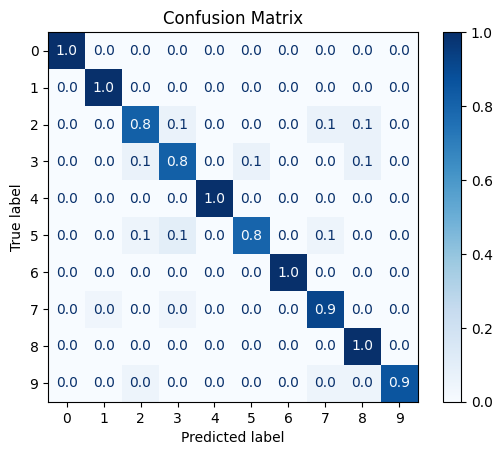

In [15]:
predictions = model.predict(test_images_preprocessed)
predicted_labels = np.argmax(predictions, axis=1)

# Calculate confusion matrix
conf_mat = confusion_matrix(test_labels, predicted_labels, normalize='true')

# Plot confusion matrix
classes = [str(i) for i in range(num_classes)]  # Replace with your actual class labels
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=classes)
disp.plot(cmap='Blues', values_format='.1f')
plt.title('Confusion Matrix')
plt.show()